# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Author:** Mohammed Umair Ali
**Course:** Data Visualization / Data Analytics
**Dataset:** `seasonal_agriculture_performance_dataset.csv`

---

## 1. Introduction

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

This notebook analyzes farm-level records across three Indian cropping seasons — **Kharif** (monsoon), **Rabi** (winter) and **Zaid** (summer) — to identify meaningful patterns, trends, relationships and differences in agricultural performance.

**Objectives:**
1. Explore and understand the dataset
2. Clean and prepare the data for analysis
3. Examine how agricultural performance varies across seasons
4. Identify important seasonal patterns and relationships
5. Compare crops, regions and irrigation methods within each season
6. Apply statistical tests and visualization techniques
7. Draw evidence-based conclusions and recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 30)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}


## 2. Data Loading & Understanding

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


**Dataset overview:** the data covers **4,000 farm records** across **8 states**, **10 districts**, **8 crops**, **3 seasons** and **4 irrigation methods**, with 22 numeric variables spanning environmental conditions (rainfall, temperature, humidity, soil), input usage (fertilizer, pesticide, water), and outcomes (yield, production, revenue, cost, profit).

In [5]:
for c in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{c} ({df[c].nunique()} unique): {sorted(df[c].unique())}")


State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season (3 unique): ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


## 3. Data Cleaning & Preparation

### 3.1 Missing values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)
print(f"\nAs % of dataset: \n{(missing/len(df)*100).round(2)}")


Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

As % of dataset: 
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


Only three columns have missing values (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`), each under 1.2% of records. Since the missingness is small and appears random (not tied to a specific season/crop), we impute using the **median of the same Season + Crop group**, which is more accurate than a single global median because these variables vary a lot by crop and season.

In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# Safety net: fill any still-missing with overall median
df.fillna(df.median(numeric_only=True), inplace=True)
print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


### 3.2 Duplicate records

In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Farm_IDs: 0


### 3.3 Outlier check

`Yield_Tonnes_Ha` shows a very wide range (0.3 to over 100 t/ha), which looks suspicious at first glance. Checking it against crop type resolves this: it isn't a data error, it's a genuine scale difference between crop types.

In [9]:
print("Median yield (t/ha) by crop:")
print(df.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values())


Median yield (t/ha) by crop:
Crop
Pulses        0.9350
Cotton        1.2350
Groundnut     1.3800
Chilli        1.5600
Wheat         2.2275
Rice          2.4600
Maize         2.8400
Sugarcane    47.8800
Name: Yield_Tonnes_Ha, dtype: float64


**Sugarcane** is a high-biomass crop that is genuinely harvested at 40-100+ tonnes/hectare, unlike grain crops (Wheat, Rice, Maize, Pulses) which fall in the 1-3 t/ha range. So the "outliers" are real Sugarcane records, not errors — we keep them, but we'll be careful to separate Sugarcane out (or use log scale / medians) when comparing yield visually so it doesn't dominate the axis.

### 3.4 Derived columns

In [10]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Is_Loss_Making'] = df['Profit_INR'] < 0
print("Data cleaning complete. Final shape:", df.shape)


Data cleaning complete. Final shape: (4000, 30)


## 4. Exploratory Data Analysis: Seasonal Patterns

### 4.1 Record distribution & environmental conditions across seasons

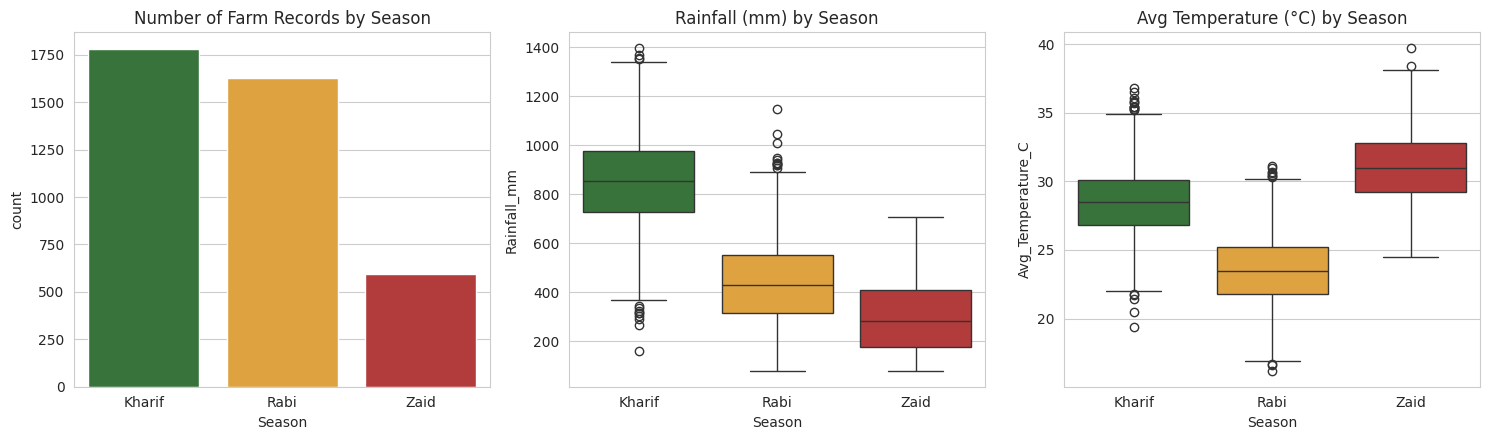

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, x='Season', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Number of Farm Records by Season')
sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Rainfall (mm) by Season')
sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[2])
axes[2].set_title('Avg Temperature (°C) by Season')
plt.tight_layout()
plt.show()


In [12]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','Disease_Pest_Risk_pct']
df.groupby('Season')[env_cols].mean().reindex(SEASON_ORDER).round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,852.10,28.45,71.81,6.79,6.73,31.20,54.47
Rabi,435.95,23.49,57.89,7.59,6.67,24.05,40.48
Zaid,299.16,31.04,52.01,8.18,6.69,19.18,38.22


**Observations:**
- **Kharif** (monsoon season) has by far the highest rainfall (~852 mm avg) and highest humidity — as expected for the monsoon cropping season.
- **Zaid** (summer season) is the driest (~299 mm) and hottest, with the fewest records (589 vs ~1,700+ for Kharif/Rabi), reflecting that fewer farms cultivate in the harsh summer window.
- **Disease/Pest risk is highest in Kharif** and lowest in Zaid — consistent with humid, rainy conditions favoring pest and disease pressure.

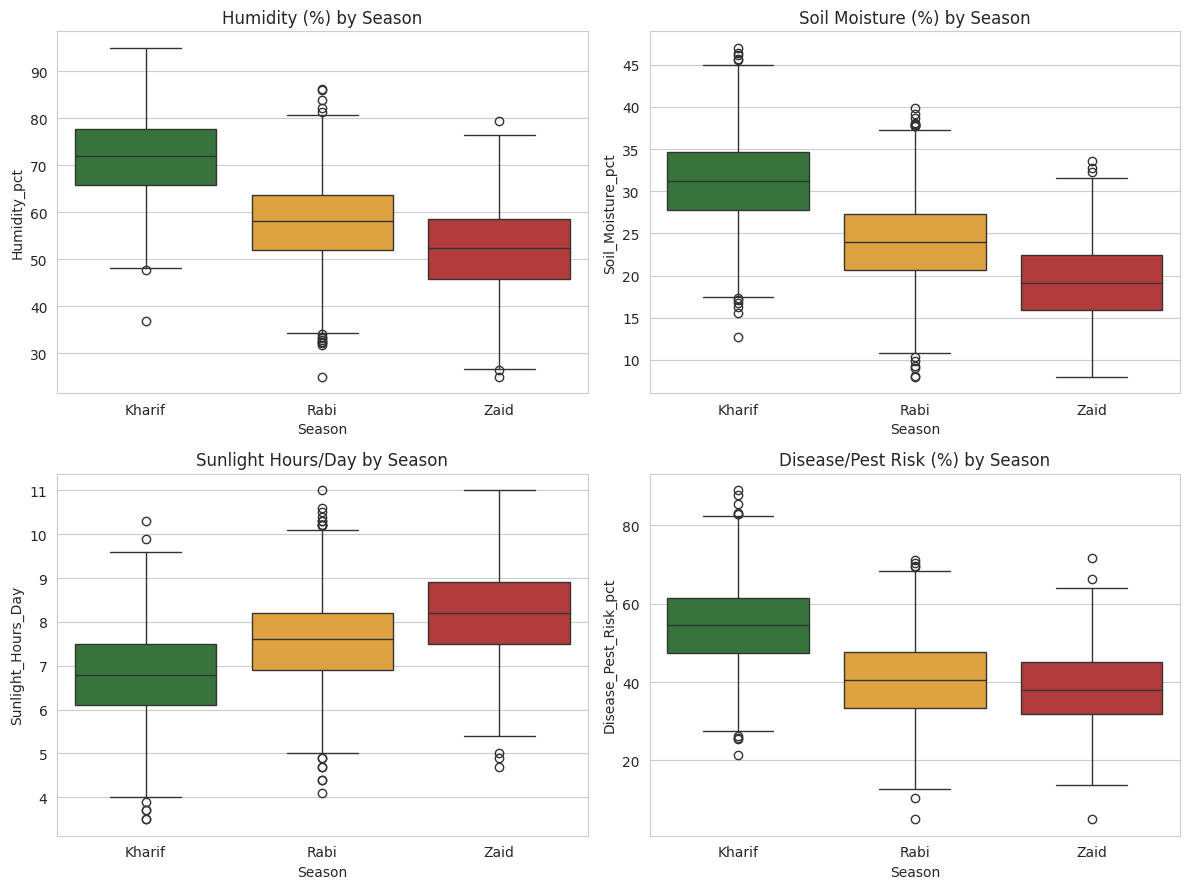

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.boxplot(data=df, x='Season', y='Humidity_pct', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[0,0]); axes[0,0].set_title('Humidity (%) by Season')
sns.boxplot(data=df, x='Season', y='Soil_Moisture_pct', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[0,1]); axes[0,1].set_title('Soil Moisture (%) by Season')
sns.boxplot(data=df, x='Season', y='Sunlight_Hours_Day', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[1,0]); axes[1,0].set_title('Sunlight Hours/Day by Season')
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[1,1]); axes[1,1].set_title('Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.show()


### 4.2 Crop mix across seasons

Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif     185     215        193    234     221   314        125    292
Rabi       163     201        177    233     213   274        129    237
Zaid        64      92         54     84      62   102         51     85


/tmp/ipykernel_894/2533863788.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_pct = ct.div(ct.sum(1), axis=0) * 100


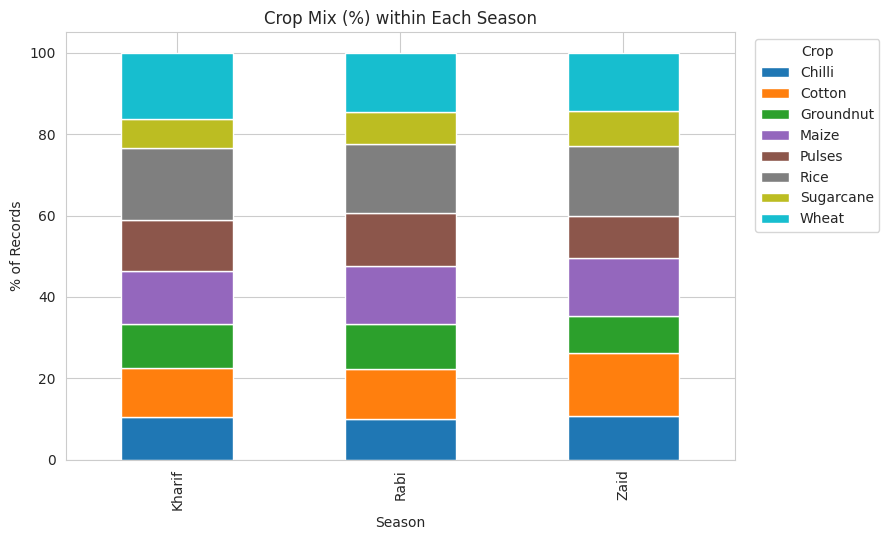

In [14]:
ct = pd.crosstab(df['Season'], df['Crop']).reindex(SEASON_ORDER)
print(ct)
ct_pct = ct.div(ct.sum(1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
ct_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Crop Mix (%) within Each Season')
ax.set_ylabel('% of Records')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Crop')
plt.tight_layout()
plt.show()


Crop mix is fairly similar proportionally across seasons (Rice and Wheat/Cotton remain the largest categories in each), though Zaid has noticeably fewer total records across all crops, confirming it is the least-cultivated season overall.

### 4.3 Yield and production across seasons

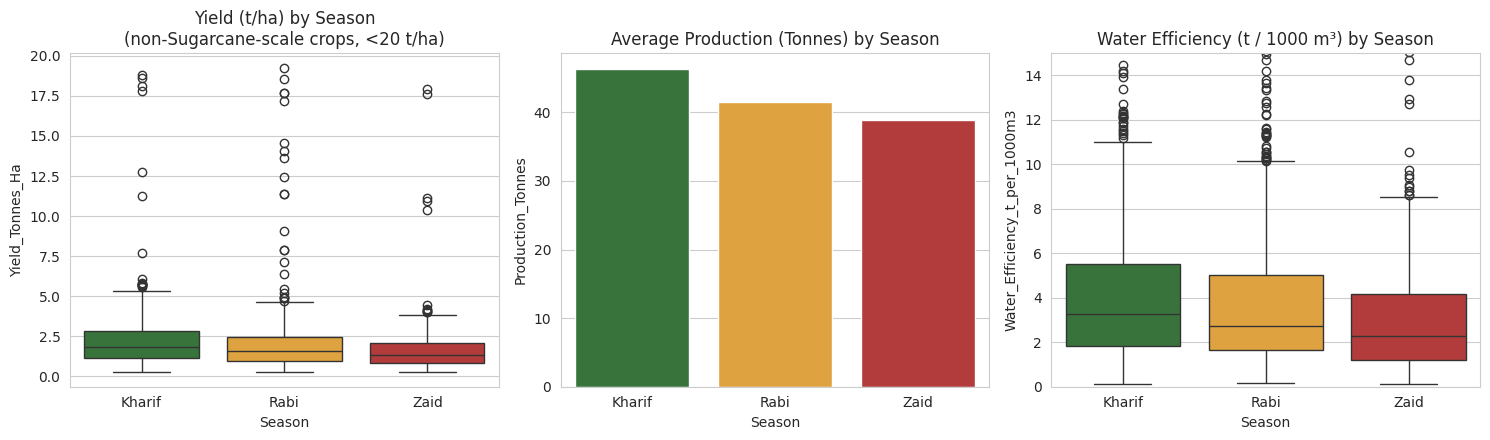

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df[df['Yield_Tonnes_Ha'] < 20], x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Yield (t/ha) by Season\n(non-Sugarcane-scale crops, <20 t/ha)')
sns.barplot(data=df, x='Season', y='Production_Tonnes', order=SEASON_ORDER, hue='Season', palette=PALETTE, estimator=np.mean, errorbar=None, legend=False, ax=axes[1])
axes[1].set_title('Average Production (Tonnes) by Season')
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER, hue='Season', palette=PALETTE, legend=False, ax=axes[2])
axes[2].set_ylim(0, 15)
axes[2].set_title('Water Efficiency (t / 1000 m³) by Season')
plt.tight_layout()
plt.show()


In [16]:
df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes','Water_Efficiency_t_per_1000m3']].median().reindex(SEASON_ORDER).round(2)


,Yield_Tonnes_Ha,Production_Tonnes,Water_Efficiency_t_per_1000m3
Season,,,
Kharif,1.95,13.24,3.28
Rabi,1.66,11.08,2.74
Zaid,1.45,9.97,2.30


**Observation:** Median yield is fairly close across seasons (crop mix drives yield far more than season does), but **Kharif shows slightly higher production and water efficiency**, likely due to natural rainfall supplementing irrigation.

### 4.4 Economic performance across seasons — the sharpest seasonal difference

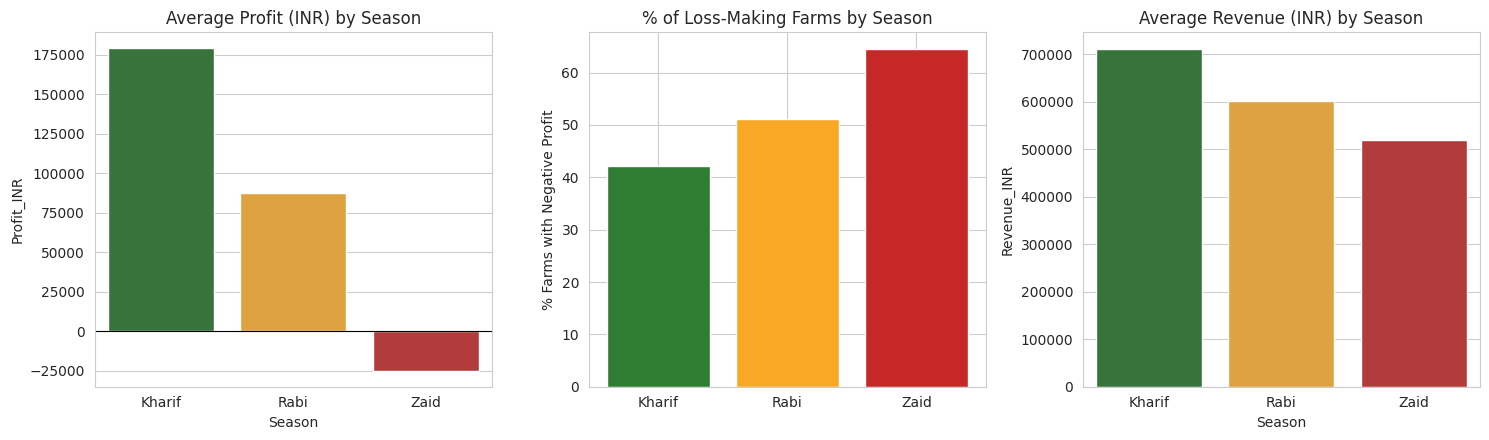

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.barplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, hue='Season', palette=PALETTE, estimator=np.mean, errorbar=None, legend=False, ax=axes[0])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Average Profit (INR) by Season')

loss_pct = df.groupby('Season')['Is_Loss_Making'].mean().reindex(SEASON_ORDER) * 100
axes[1].bar(loss_pct.index, loss_pct.values, color=[PALETTE[s] for s in loss_pct.index])
axes[1].set_title('% of Loss-Making Farms by Season')
axes[1].set_ylabel('% Farms with Negative Profit')

sns.barplot(data=df, x='Season', y='Revenue_INR', order=SEASON_ORDER, hue='Season', palette=PALETTE, estimator=np.mean, errorbar=None, legend=False, ax=axes[2])
axes[2].set_title('Average Revenue (INR) by Season')
plt.tight_layout()
plt.show()


In [18]:
econ = df.groupby('Season').agg(
    Avg_Revenue=('Revenue_INR','mean'),
    Avg_Cost=('Total_Cost_INR','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Median_Profit=('Profit_INR','median'),
    Pct_Loss_Making=('Is_Loss_Making', lambda x: x.mean()*100),
).reindex(SEASON_ORDER).round(1)
econ


,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Pct_Loss_Making
Season,,,,,
Kharif,710719.1,531804.4,178914.6,38808.0,42.2
Rabi,601526.0,513836.6,87689.5,-3187.0,51.1
Zaid,519171.9,543976.7,-24804.8,-62144.0,64.5


**This is the single most important seasonal pattern in the dataset:**
- **Kharif is by far the most profitable season** — average profit of ~₹1.79 lakh, with only 42% of farms loss-making.
- **Zaid (summer) performs the worst economically** — average profit is **negative** (~-₹25,000), with **64.5% of farms operating at a loss**.
- Revenue drops steadily from Kharif → Rabi → Zaid, while cost stays roughly flat across seasons — so the profit decline is a **revenue problem** (lower yields/production and possibly weaker seasonal prices), not a cost problem.

### 4.5 Profitability by crop within each season

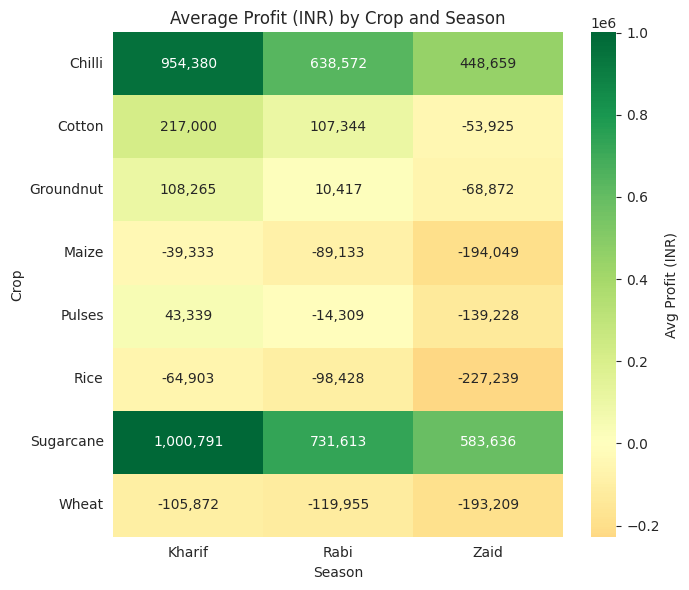

In [19]:
pv = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')[SEASON_ORDER]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pv, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Avg Profit (INR)'})
ax.set_title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.show()


**Key insight:** the Kharif > Rabi > Zaid profitability ranking holds for almost every crop individually — so this isn't an artifact of crop mix, it's a genuine seasonal effect. Separately, **crop choice matters more than season**: Sugarcane and Chilli are profitable in every season, while Maize, Rice and Wheat run at a loss in every season. The most reliable combination in this dataset is a high-value crop (Sugarcane/Chilli) grown in Kharif.

### 4.6 Irrigation method: efficiency and profitability

In [20]:
irr = df.groupby('Irrigation_Method')[['Water_Efficiency_t_per_1000m3','Profit_INR']].mean().sort_values('Profit_INR', ascending=False)
irr.round(2)


,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,
Drip,6.27,219626.00
Sprinkler,4.67,91121.08
Rainfed,7.56,79050.37
Flood,3.44,73354.02


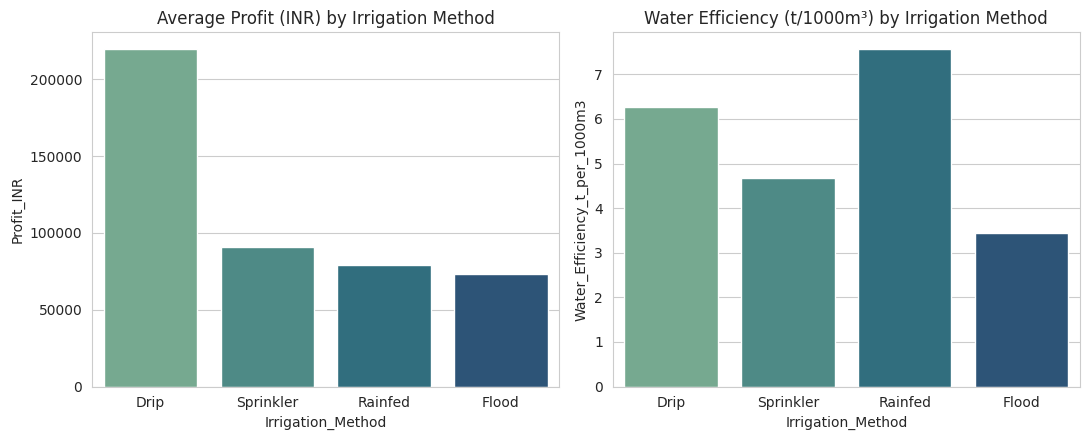

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(x=irr.index, y=irr['Profit_INR'], hue=irr.index, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Average Profit (INR) by Irrigation Method')
sns.barplot(x=irr.index, y=irr['Water_Efficiency_t_per_1000m3'], hue=irr.index, palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Water Efficiency (t/1000m³) by Irrigation Method')
plt.tight_layout()
plt.show()


**Drip irrigation** produces the highest average profit (~₹2.20 lakh) of any method — more than double Flood or Sprinkler — even though Rainfed shows a slightly higher raw water-efficiency number (likely because rainfed farms use very little supplemental water in the denominator). This makes drip irrigation adoption a strong, actionable recommendation regardless of season.

### 4.7 Regional (state-level) comparison

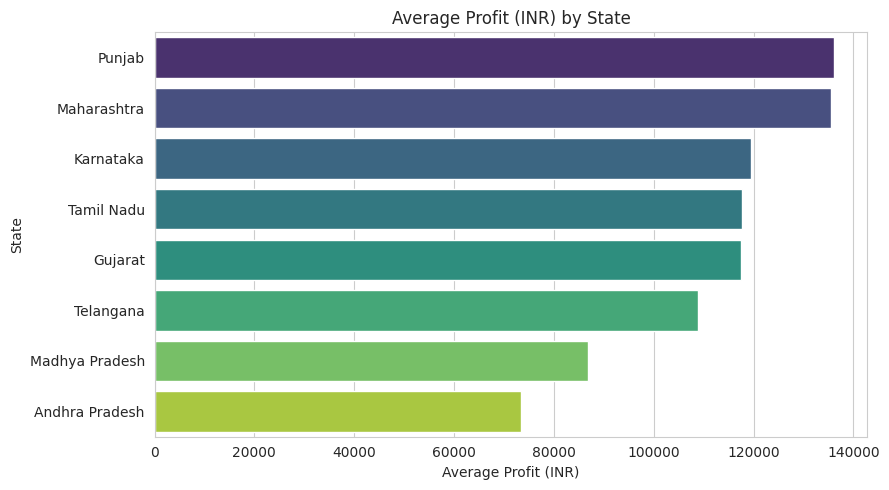

In [22]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=state_profit.values, y=state_profit.index, hue=state_profit.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Average Profit (INR) by State')
ax.set_xlabel('Average Profit (INR)')
plt.tight_layout()
plt.show()


Punjab and Maharashtra show the highest average profitability, while Andhra Pradesh is lowest — but the spread across states (₹73k-₹136k) is much narrower than the spread across seasons (-₹25k to +₹179k) or across crops (up to ₹1M+), confirming that **season and crop choice are stronger drivers of profitability than geography** in this dataset.

### 4.8 Correlation analysis

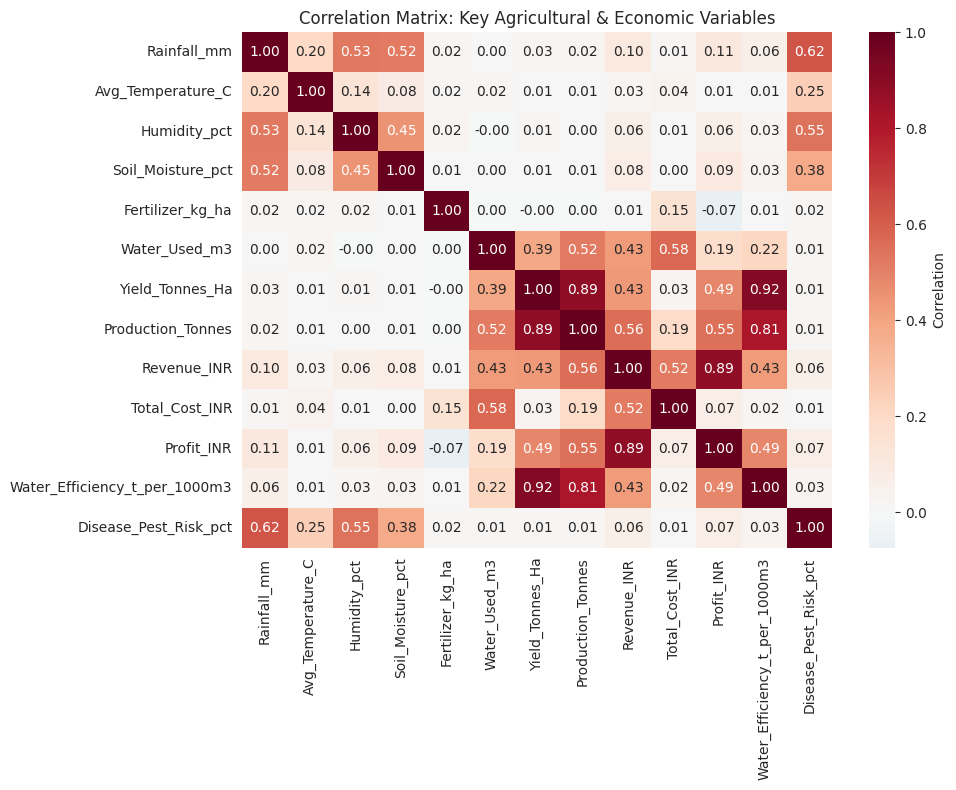

In [23]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Fertilizer_kg_ha',
            'Water_Used_m3','Yield_Tonnes_Ha','Production_Tonnes','Revenue_INR','Total_Cost_INR',
            'Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Key Agricultural & Economic Variables')
plt.tight_layout()
plt.show()


In [24]:
print("Correlation of each variable with Profit_INR:")
df[num_cols].corr()['Profit_INR'].sort_values(ascending=False)


Correlation of each variable with Profit_INR:


Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489350
Water_Used_m3                    0.190278
Rainfall_mm                      0.105972
Soil_Moisture_pct                0.092204
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Avg_Temperature_C                0.009043
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64

**Profit is driven mainly by Revenue, Production, Yield and Water Efficiency** (all positively correlated, 0.49-0.89). Environmental variables (rainfall, temperature, humidity, soil moisture) and input levels (fertilizer, water volume) show weak direct correlation with profit — their effect on profit is indirect, working through yield/production rather than acting on profit directly. Fertilizer usage in particular shows a slightly *negative* correlation with profit, hinting at possible over-application on lower-performing farms rather than a direct causal harm.

## 5. Statistical Testing

To confirm which seasonal differences are statistically significant (not just visual), we run one-way ANOVA tests across the three seasons for key metrics.

In [25]:
print(f"{'Metric':<32}{'F-statistic':>14}{'p-value':>14}   Significant?")
print("-"*80)
for col in ['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Rainfall_mm',
            'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']:
    groups = [g[col].dropna().values for _, g in df.groupby('Season')]
    f, p = stats.f_oneway(*groups)
    sig = "Yes (p<0.05)" if p < 0.05 else "No"
    print(f"{col:<32}{f:>14.2f}{p:>14.4g}   {sig}")


Metric                             F-statistic       p-value   Significant?
--------------------------------------------------------------------------------
Yield_Tonnes_Ha                           1.46        0.2328   No
Production_Tonnes                         1.03        0.3585   No
Profit_INR                               34.29     1.712e-15   Yes (p<0.05)
Rainfall_mm                            3448.57             0   Yes (p<0.05)
Water_Efficiency_t_per_1000m3             6.95     0.0009719   Yes (p<0.05)
Disease_Pest_Risk_pct                  1049.47             0   Yes (p<0.05)


**Interpretation:**
- **Rainfall, Disease/Pest Risk, Water Efficiency and Profit differ significantly across seasons** (p < 0.05) — these are genuine seasonal effects, not random noise.
- **Yield and Production do not differ significantly by season** — yield is driven far more by crop type than by which season a crop is grown in, confirming the pattern seen in the crop x season heatmap.


## 6. Key Findings

1. **Kharif is the most profitable and most cultivated season**, benefiting from the highest natural rainfall (~852 mm avg) and water efficiency; **Zaid (summer) is the weakest season economically**, with average profit turning *negative* and 64.5% of Zaid farms operating at a loss.
2. **Nearly half of all farms in the dataset (49.2%) are loss-making overall** — this is a widespread profitability problem, not an isolated one.
3. **Disease/Pest risk is highest in Kharif** (54.5% avg) and lowest in Zaid (38.2% avg), tracking the higher humidity and rainfall of the monsoon season.
4. **Crop choice matters more than season for profitability**: Sugarcane and Chilli are profitable in every season studied, while Maize, Rice and Wheat run at a loss in every season — the Kharif > Rabi > Zaid profitability ranking holds *within* almost every crop, so the two effects are independent and additive.
5. **Drip irrigation delivers roughly double the average profit** of Flood or Sprinkler methods, making it the strongest actionable lever for improving farm economics independent of season.
6. **Profit is driven primarily by revenue-side factors** (yield, production, water efficiency) rather than by cost or raw environmental conditions, which only affect profit indirectly through yield.
7. **Regional (state) differences in profitability are real but modest** compared to the effects of season and crop choice.

## 7. Recommendations

- **Prioritize Kharif-season cultivation** where feasible, and treat Zaid (summer) cultivation as higher-risk, requiring stronger price/cost planning or crop substitution.
- **Promote drip irrigation adoption**, especially for farms currently on Flood or Sprinkler systems, given its consistent profit advantage.
- **Reassess Maize, Rice and Wheat cultivation economics** — these crops are structurally loss-making across all three seasons in this dataset, and either input-cost reduction, yield improvement, or crop diversification (toward Sugarcane/Chilli where regionally viable) should be investigated.
- **Strengthen pest/disease management specifically for Kharif season** crops, where risk is highest.
- **Use season- and crop-specific benchmarks** (not single dataset-wide averages) when advising farmers, since season and crop each independently swing profit by large margins.

## 8. Conclusion

This analysis confirms that **agricultural performance varies significantly by season** — primarily through economic outcomes (profit, revenue) and risk factors (disease/pest pressure, rainfall) rather than through yield itself, which is more strongly tied to crop type. Kharif is the strongest season overall; Zaid is the weakest. Combining seasonal timing with the right crop and irrigation choice offers the most actionable path to improving agricultural profitability in this dataset.
